In [1]:
import sys
print(sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
import sklearn
print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.9.1


In [3]:
import pandas as pd

df = pd.read_csv("EV_Predictive_Maintenance_Dataset_15min.csv")

print(df.shape)

(175393, 30)


In [4]:
features = [
    "SoC",
    "SoH",
    "Battery_Voltage",
    "Battery_Current",
    "Battery_Temperature",
    "Charge_Cycles",
    "Motor_Temperature",
    "Motor_Vibration",
    "Motor_Torque",
    "Motor_RPM",
    "Power_Consumption",
    "Brake_Pad_Wear",
    "Brake_Pressure",
    "Reg_Brake_Efficiency",
    "Tire_Pressure",
    "Tire_Temperature",
    "Suspension_Load",
    "Ambient_Temperature",
    "Ambient_Humidity",
    "Load_Weight",
    "Driving_Speed",
    "Distance_Traveled",
    "Idle_Time",
    "Route_Roughness"
]

X = df[features]
y = df["Failure_Probability"]

print("X:", X.shape)
print("y:", y.shape)

X: (175393, 24)
y: (175393,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (140314, 24)
Testing: (35079, 24)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)
  
print("Model training completed!")

Model training completed!


C:\Users\saika\Documents\EVProject\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 0 0 0 1]


In [9]:
from sklearn.metrics import accuracy_score, precis ion_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.4868439807292112
Precision: 0.09796979587320905
Recall   : 0.5109636468551645
F1-Score : 0.16441535533583995


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model2 = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ))
])

model2.fit(X_train, y_train)

print("Improved model training completed!")

Improved model training completed!


In [11]:
y_pred2 = model2.predict(X_test)

print(y_pred2[:20])

[0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 0 0 0 1]


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy2 = accuracy_score(y_test, y_pred2)
precision2 = precision_score(y_test, y_pred2)
recall2 = recall_score(y_test, y_pred2)
f1_2 = f1_score(y_test, y_pred2)

print("Accuracy :", accuracy2)
print("Precision:", precision2)
print("Recall   :", recall2)
print("F1-Score :", f1_2)

Accuracy : 0.49593774052852135
Precision: 0.09819106840022612
Recall   : 0.5011540680900173
F1-Score : 0.1642087351106069


In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier

model3 = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

model3.fit(X_train, y_train)

print("Model 3 training completed!")

Model 3 training completed!


In [14]:
y_pred3 = model3.predict(X_test)

print(y_pred3[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy3 = accuracy_score(y_test, y_pred3)
precision3 = precision_score(y_test, y_pred3, zero_division=0)
recall3 = recall_score(y_test, y_pred3, zero_division=0)
f1_3 = f1_score(y_test, y_pred3, zero_division=0)

print("Accuracy :", accuracy3)
print("Precision:", precision3)
print("Recall   :", recall3)
print("F1-Score :", f1_3)

Accuracy : 0.9011944468200348
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0


In [16]:
print("Actual failures :", sum(y_test))
print("Predicted failures:", sum(y_pred3))

Actual failures : 3466
Predicted failures: 0


In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier

model4 = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    class_weight="balanced",
    random_state=42
)

model4.fit(X_train, y_train)

print("Model 4 training completed!")

Model 4 training completed!


In [18]:
y_pred4 = model4.predict(X_test)

print(y_pred4[:20])

[1 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 0 0]


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy4 = accuracy_score(y_test, y_pred4)
precision4 = precision_score(y_test, y_pred4, zero_division=0)
recall4 = recall_score(y_test, y_pred4, zero_division=0)
f1_4 = f1_score(y_test, y_pred4, zero_division=0)

print("Accuracy :", accuracy4)
print("Precision:", precision4)
print("Recall   :", recall4)
print("F1-Score :", f1_4)

Accuracy : 0.5957980558168705
Precision: 0.10331037547211731
Recall   : 0.4024812463935372
F1-Score : 0.16441746714597208


In [20]:
print(df["Failure_Probability"].value_counts())
print()
print(df["Failure_Probability"].value_counts(normalize=True) * 100)

Failure_Probability
0    158061
1     17332
Name: count, dtype: int64

Failure_Probability
0    90.118192
1     9.881808
Name: proportion, dtype: float64


In [21]:
df.groupby("Failure_Probability")[[
    "SoC",
    "SoH",
    "Battery_Voltage",
    "Battery_Current",
    "Battery_Temperature",
    "Charge_Cycles"
]].mean()

,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles
Failure_Probability,,,,,,
0,0.779513,0.882398,352.713585,-47.858513,33.393997,217.773970
1,0.783242,0.880588,352.712543,-48.202373,33.448123,216.874887


In [22]:
correlation = df[features + ["Failure_Probability"]].corr()["Failure_Probability"]

print(correlation.sort_values(ascending=False))

Failure_Probability     1.000000
SoC                     0.003815
Distance_Traveled       0.002870
Idle_Time               0.002842
Ambient_Humidity        0.001904
Battery_Temperature     0.001866
Motor_RPM               0.001136
Motor_Vibration         0.001009
Suspension_Load         0.000894
Ambient_Temperature     0.000212
Battery_Voltage        -0.000006
Motor_Temperature      -0.000461
Tire_Pressure          -0.000473
Tire_Temperature       -0.000539
Motor_Torque           -0.000983
Power_Consumption      -0.001213
Brake_Pad_Wear         -0.001259
Driving_Speed          -0.001622
Charge_Cycles          -0.001631
Load_Weight            -0.001677
Brake_Pressure         -0.001904
Battery_Current        -0.002262
Route_Roughness        -0.002832
Reg_Brake_Efficiency   -0.003270
SoH                    -0.003277
Name: Failure_Probability, dtype: float64


In [23]:
print(df.groupby("Failure_Probability")[[
    "RUL",
    "TTF",
    "Component_Health_Score"
]].mean())

                            RUL         TTF  Component_Health_Score
Failure_Probability                                                
0                    216.339508  129.720960                0.744562
1                    216.610143  129.750408                0.743305


In [24]:
print(df.groupby("Failure_Probability")[[
    "SoH",
    "RUL",
    "TTF",
    "Component_Health_Score"
]].agg(["min", "max"]))

                          SoH                 RUL                   TTF  \
                          min       max       min         max       min   
Failure_Probability                                                       
0                    0.400001  0.999999  0.000148  299.999891  0.000009   
1                    0.400007  0.999999  0.013646  299.999378  0.002934   

                                Component_Health_Score            
                            max                    min       max  
Failure_Probability                                               
0                    199.998920               0.000005  0.999999  
1                    199.991666               0.000029  0.999997  


In [2]:
import pandas as pd

df = pd.read_csv("EV_Predictive_Maintenance_Dataset_15min.csv")

print(df.shape)

(175393, 30)


In [3]:
features = [
    "SoC",
    "SoH",
    "Battery_Voltage",
    "Battery_Current",
    "Battery_Temperature",
    "Charge_Cycles",
    "Motor_Temperature",
    "Motor_Vibration",
    "Motor_Torque",
    "Motor_RPM",
    "Power_Consumption",
    "Brake_Pad_Wear",
    "Brake_Pressure",
    "Reg_Brake_Efficiency",
    "Tire_Pressure",
    "Tire_Temperature",
    "Suspension_Load",
    "Ambient_Temperature",
    "Ambient_Humidity",
    "Load_Weight",
    "Driving_Speed",
    "Distance_Traveled",
    "Idle_Time",
    "Route_Roughness"
]

X = df[features]
y = df["Failure_Probability"]

print("X:", X.shape)
print("y:", y.shape)

X: (175393, 24)
y: (175393,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (140314, 24)
Testing: (35079, 24)


In [5]:
from sklearn.ensemble import HistGradientBoostingClassifier

model4 = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    class_weight="balanced",
    random_state=42
)

model4.fit(X_train, y_train)

print("Model 4 trained successfully!")

Model 4 trained successfully!


In [6]:
from sklearn.metrics import log_loss

y_prob = model4.predict_proba(X_test)[:, 1]

loss = log_loss(y_test, y_prob)

print("Loss:", loss)

Loss: 0.6889769482353896


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model4.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-Score :", f1_score(y_test, y_pred, zero_division=0))

Accuracy : 0.5957980558168705
Precision: 0.10331037547211731
Recall   : 0.4024812463935372
F1-Score : 0.16441746714597208


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

y_pred = model4.predict(X_test)
y_prob = model4.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
loss = log_loss(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("Log Loss :", loss)

Accuracy : 0.5957980558168705
Precision: 0.10331037547211731
Recall   : 0.4024812463935372
F1-Score : 0.16441746714597208
Log Loss : 0.6889769482353896


In [9]:
import joblib

joblib.dump(model4, "battery_failure_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [10]:
sample = X_test.iloc[0:1]

prediction = model4.predict(sample)[0]

if prediction == 1:
    print("Prediction: Failure Risk")
else:
    print("Prediction: Normal")

Prediction: Failure Risk


In [11]:
samples = X_test.iloc[:5]

predictions = model4.predict(samples)

for i, prediction in enumerate(predictions):
    if prediction == 1:
        print(f"Sample {i+1}: Failure Risk")
    else:
        print(f"Sample {i+1}: Normal")

Sample 1: Failure Risk
Sample 2: Normal
Sample 3: Normal
Sample 4: Failure Risk
Sample 5: Normal


In [12]:
import joblib

joblib.dump(features, "battery_features.pkl")

print("Features saved successfully!")

Features saved successfully!


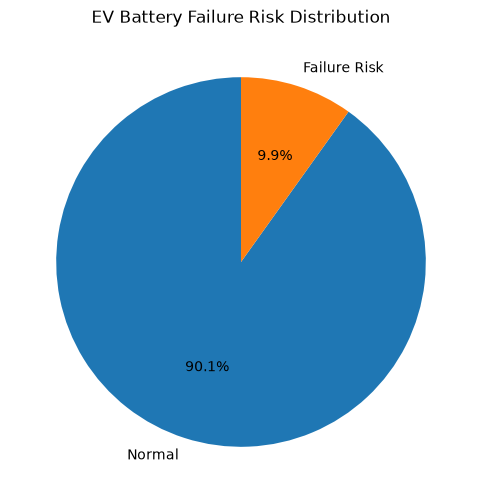

In [13]:
import matplotlib.pyplot as plt

counts = df["Failure_Probability"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=["Normal", "Failure Risk"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("EV Battery Failure Risk Distribution")
plt.show()

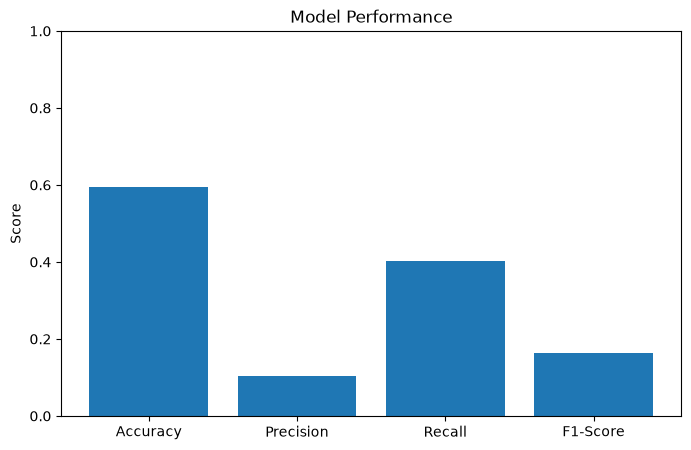

In [14]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values())

plt.title("Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

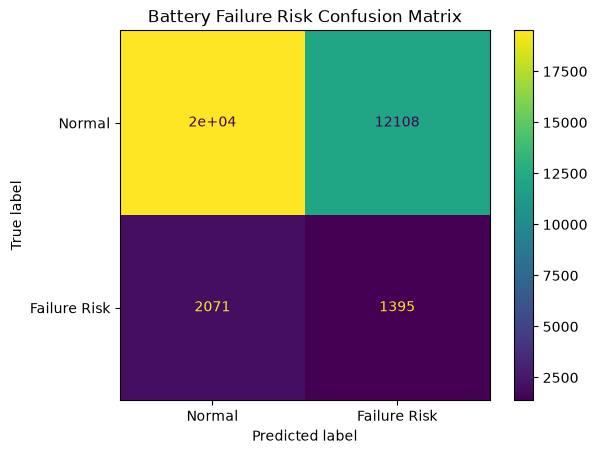

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Failure Risk"]
)

disp.plot()
plt.title("Battery Failure Risk Confusion Matrix")
plt.show()

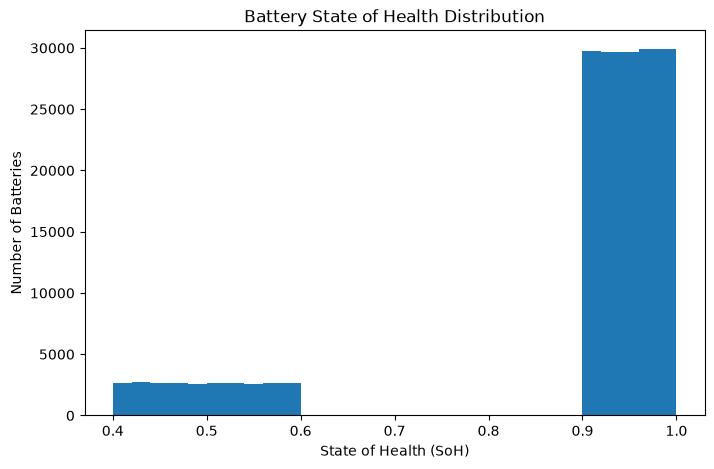

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df["SoH"], bins=30)

plt.title("Battery State of Health Distribution")
plt.xlabel("State of Health (SoH)")
plt.ylabel("Number of Batteries")

plt.show()

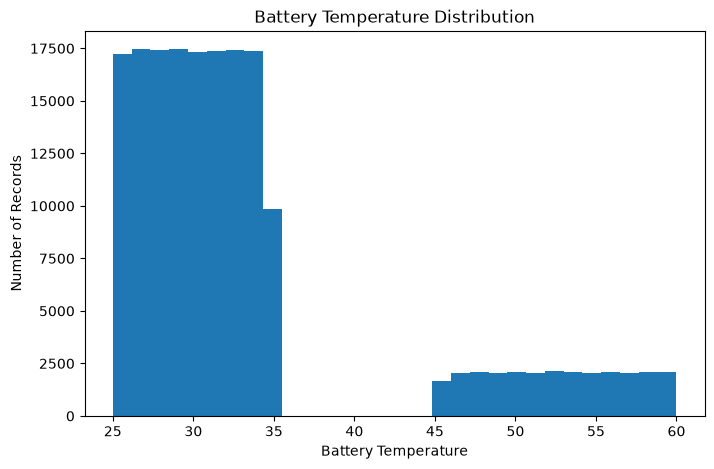

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df["Battery_Temperature"], bins=30)

plt.title("Battery Temperature Distribution")
plt.xlabel("Battery Temperature")
plt.ylabel("Number of Records")

plt.show()

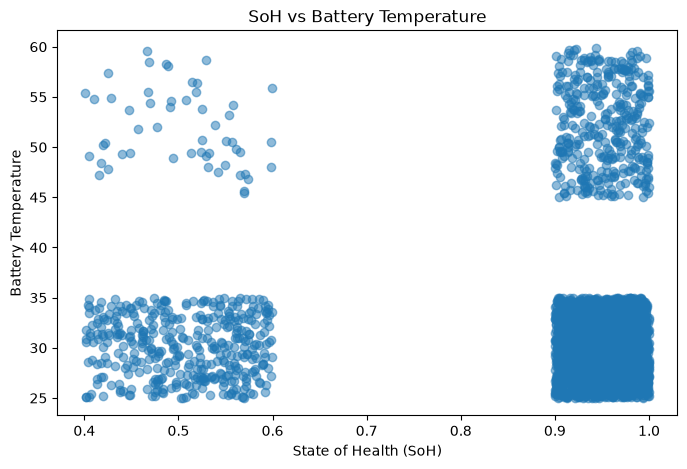

In [18]:
sample = df.sample(3000, random_state=42)

plt.figure(figsize=(8,5))

plt.scatter(
    sample["SoH"],
    sample["Battery_Temperature"],
    alpha=0.5
)

plt.title("SoH vs Battery Temperature")
plt.xlabel("State of Health (SoH)")
plt.ylabel("Battery Temperature")

plt.show()